## Welcome back to Python Notebooks!

Didja miss me??

### And welcome to Week 4, Day 2 - introducing LangGraph!

In [ ]:
# !/home/marley/tmp/The-Complete-Agentic-AI-Engineering-Course/setup/.venv/bin/python -m ensurepip --default-pip
#/home/marley/tmp/The-Complete-Agentic-AI-Engineering-Course/setup/.venv/bin/python -m pip install --upgrade pip
%pip install typing langgraph langchain-openai gradio pydantic ipython -q
%pip list | grep -E "langgraph|langchain-openai|gradio|pydantic|ipython"

Note: you may need to restart the kernel to use updated packages.
gradio                    6.14.0
gradio_client             2.5.0
hf-gradio                 0.4.1
ipython                   9.13.0
ipython_pygments_lexers   1.1.1
langchain-openai          1.3.3
langgraph                 1.2.6
langgraph-checkpoint      4.1.1
langgraph-prebuilt        1.1.0
langgraph-sdk             0.4.2
pydantic                  2.13.3
pydantic_core             2.46.3
pydantic-settings         2.14.0
Note: you may need to restart the kernel to use updated packages.


In [7]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
# from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random


In [8]:
# Some useful constants

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [ ]:
# Our favorite first step! Crew was doing this for us, by the way.
# load_dotenv(override=True)


In [9]:
def shout(text: Annotated[str, "something to be shouted"]) -> str:
    print(text.upper())
    return text.upper()

shout("hello")

HELLO


'HELLO'

### A word about "Annotated"

You probably know this; type hinting is a feature in Python that lets you specify the type of something:

`my_favorite_things: List`

But you may not know this:

You can also use something called "Annotated" to add extra information that somebody else might find useful:

`my_favorite_things: Annotated[List, "these are a few of mine"]`

LangGraph needs us to use this feature when we define our State object.

It wants us to tell it what function it should call to update the State with a new value.

This function is called a **reducer**.

LangGraph provides a default reducer called `add_messages` which takes care of the most common case.

And that hopefully explains why the State looks like this.




### Step 1: Define the State object

You can use any python object; but it's most common to use a TypedDict or a Pydantic BaseModel.

In [10]:

class State(BaseModel):
        
    messages: Annotated[list, add_messages]


### Step 2: Start the Graph Builder with this State class

In [11]:
graph_builder = StateGraph(State)

### Step 3: Create a Node

A node can be any python function.

The reducer that we set before gets automatically called to combine this response with previous responses


In [12]:
def our_first_node(old_state: State) -> State:

    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]

    new_state = State(messages=messages)

    return new_state

graph_builder.add_node("first_node", our_first_node)

### Step 4: Create Edges

In [13]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

### Step 5: Compile the Graph

In [14]:
graph = graph_builder.compile()

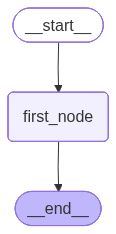

In [15]:
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! Showtime!

In [ ]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='test', additional_kwargs={}, response_metadata={}, id='2a473600-2039-468d-906e-bb889ba87336'), AIMessage(content='Cabbages are existential', additional_kwargs={}, response_metadata={}, id='a0611181-8f45-4c31-816a-011c3f9cbf32', tool_calls=[], invalid_tool_calls=[])]}
{'messages': [HumanMessage(content='aa', additional_kwargs={}, response_metadata={}, id='54d13309-ace4-4dc1-88d8-4ba7949bbf94'), AIMessage(content='Penguins are squishy', additional_kwargs={}, response_metadata={}, id='990d2bd8-f557-4d6d-be3c-2d9eda4456ed', tool_calls=[], invalid_tool_calls=[])]}


### But why did I show you that?

To make the point that LangGraph is all about python functions - it doesn't need to involve LLMs!!

Now we'll do the 5 steps again, but in 1 shot:

In [18]:
# Step 1: Define the State object
class State(BaseModel):
    messages: Annotated[list, add_messages]


In [19]:
# Step 2: Start the Graph Builder with this State class
graph_builder = StateGraph(State)


In [ ]:
BASE_URL = "https://models.github.ai/inference"
MODEL_GPT_4o_MINI = "gpt-4o-mini"
MODEL_NAME = MODEL_GPT_4o_MINI
API_KEY = "github_pat_***"

# Step 3: Create a Node

# llm = ChatOpenAI(model=MODEL_NAME)

llm = ChatOpenAI(
    model=MODEL_NAME,
    base_url=BASE_URL,
    api_key=API_KEY
)

def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("chatbot", chatbot_node)

In [22]:
# Step 4: Create Edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

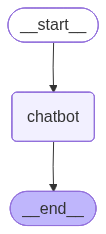

In [23]:
# Step 5: Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### That's it! And, let's do this:

In [ ]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='тест', additional_kwargs={}, response_metadata={}, id='3cc37ee3-ac68-441a-bf4f-2a7805509ba9'), AIMessage(content='Привет! Как я могу помочь вам сегодня?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 9, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 11, 'engine_ttft_ms': 24, 'engine_ttlt_ms': 146, 'pre_inference_ms': 84, 'service_tbt_ms': 13, 'service_ttft_ms': 839, 'service_ttlt_ms': 970, 'total_duration_ms': 898, 'user_visible_ttft_ms': 755}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_965c8b9ecf', 'id': 'chatcmpl-DvvBcJn7D9GtJIS5qCgPdz0qH41qo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, i